In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from turbos.sim.p3d.p3d_2 import P3D
import matplotlib.pyplot as plt

In [3]:

run = P3D(
    "/archive/tulasi/MEGARUNS_DATA_SUBSET/149p6",
    filenum="000",
)
#419
ds = run.load_xarray(419, variables=['Pe', 'ue', 'Pi', 'ui', 'J', 'E'])
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (x: 4096, y: 4096, j: 3, i: 3, c: 3)
Coordinates:
  * x        (x) float64 33kB 0.0 0.03652 0.07305 0.1096 ... 149.5 149.5 149.6
  * y        (y) float64 33kB 0.0 0.03652 0.07305 0.1096 ... 149.5 149.5 149.6
  * j        (j) <U1 12B 'x' 'y' 'z'
  * i        (i) <U1 12B 'x' 'y' 'z'
  * c        (c) <U1 12B 'x' 'y' 'z'
Data variables:
    Pe       (x, y, i, j) float32 604MB 0.3033 -0.007991 ... 0.0205 0.403
    ue       (x, y, c) float32 201MB 0.01591 0.0244 ... 0.04151 -0.009202
    Pi       (x, y, i, j) float32 604MB 0.3142 -0.01473 ... -0.01141 0.3694
    ui       (x, y, c) float32 201MB 0.04301 0.02117 -0.1289 ... 0.01257 -0.1358
    J        (x, y, c) float32 201MB 0.03226 -0.01035 ... -0.04091 -0.1015
    E        (x, y, c) float32 201MB -0.04819 -0.005673 ... -0.003643 -0.009639
Attributes:
    time:      209.5
    run:       149p6
    snapshot:  419
    format:    hdf5


In [ ]:
from turbos.filter import kfilter
# ds['Pe'] = kfilter(ds['Pe'], 13)
# ds['ue'] = kfilter(ds['ue'], 13)
# ds['Pi'] = kfilter(ds['Pi'], 13)
# ds['ui'] = kfilter(ds['ui'], 13)

for name, da in ds.data_vars.items():

    if {"x", "y"}.issubset(da.dims):
        ds[name] = kfilter(
            da,
            kcut=20,
        )

In [5]:
from turbos.pressure_strain import pressure_strain
PSe = pressure_strain(ds['Pe'], ds['ue'])
ds['PiDe'], ds['pthe'] = PSe['PiD'], PSe['pth']

PSi = pressure_strain(ds['Pi'], ds['ui'])
ds['PiDi'], ds['pthi']  = PSi['PiD'], PSi['pth']
ds['JE'] = (ds["J"] * ds["E"]).sum("c")

In [6]:
def standardize(da, dims=("x", "y")):
    mean = da.mean(dim=dims)
    std = da.std(dim=dims)

    return (da - mean) / std

In [7]:
pide_n = standardize(ds['PiDe'])
pidi_n = standardize(ds['PiDi'])
pthe_n = standardize(ds['pthe'])
pthi_n = standardize(ds['pthi'])
JE_n = standardize(ds['JE'])

In [8]:
print(pide_n)

<xarray.DataArray 'PiDe' (x: 4096, y: 4096)> Size: 134MB
array([[ 0.58313485,  0.56732135,  0.54269885, ...,  0.8772566 ,
         0.85078914,  0.86723511],
       [ 0.53970714,  0.55379205,  0.58071109, ...,  0.78153577,
         0.74274748,  0.75588016],
       [ 0.33675109,  0.39866372,  0.49951026, ...,  0.56034704,
         0.48864723,  0.49616255],
       ...,
       [-0.05487999, -0.2381591 , -0.53316952, ...,  0.84806812,
         0.72073951,  0.67442473],
       [ 0.28144636,  0.13240078, -0.09282902, ...,  0.9378931 ,
         0.87152301,  0.84774949],
       [ 0.5063069 ,  0.38499217,  0.21507617, ...,  0.97959184,
         0.95141842,  0.94108826]], shape=(4096, 4096))
Coordinates:
  * x        (x) float64 33kB 0.0 0.03652 0.07305 0.1096 ... 149.5 149.5 149.6
  * y        (y) float64 33kB 0.0 0.03652 0.07305 0.1096 ... 149.5 149.5 149.6
Attributes:
    kfilter_cutoff:  15


In [9]:
# import numpy as np
# f, ax = plt.subplots(1,2, sharey= True)

# thr1 = 2.4
# thr2 = 2.4

# cmap = plt.colormaps["viridis"].with_extremes(under="white", over="red")


# pide_thr = dse.where(
#     np.abs(dse) > thr1
# )


# pidi_thr = dsi.where(
#     np.abs(dsi) > thr2
# )

# xx = ds["x"].values
# c0 = ax[0].imshow(pide_thr.transpose(), origin = 'lower', cmap= cmap, vmin = thr1)
# c1 = ax[1].imshow(pidi_thr.transpose(), origin = 'lower', cmap= cmap, vmin = thr2)

# for a in ax:
#     a.set_aspect('equal')
# plt.tight_layout()
# plt.show()

In [10]:
pide_n.values.flatten()

array([0.58313485, 0.56732135, 0.54269885, ..., 0.97959184, 0.95141842,
       0.94108826], shape=(16777216,))

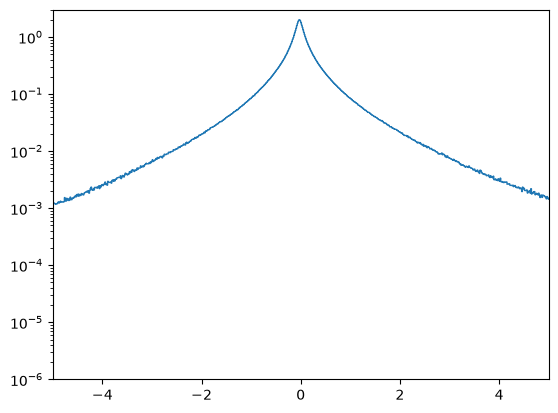

In [11]:
plt.hist(pide_n.values.flatten(), bins=6000, density = True, histtype = 'step')
plt.xlim(-5, 5)
plt.ylim(1e-6, 3)
plt.yscale('log')

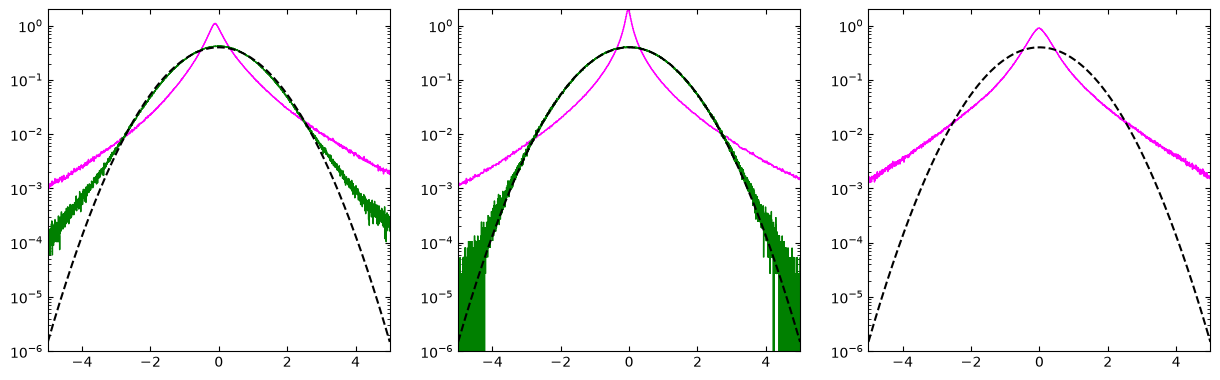

In [13]:
from scipy.stats import gaussian_kde, norm
import numpy as np
from scipy.stats import norm

f, ax = plt.subplots(1, 3, figsize=(15, 5))

nbins = 5000
ax[0].hist(pidi_n.values.flatten(), bins=nbins, density=True, histtype='step', edgecolor = 'magenta')
ax[0].hist(pthi_n.values.flatten(), bins=nbins, density=True, histtype='step', edgecolor = 'green')
ax[1].hist(pide_n.values.flatten(), bins=nbins, density=True, histtype='step', edgecolor = 'magenta')
ax[1].hist(pthe_n.values.flatten(), bins=nbins, density=True, histtype='step', edgecolor = 'green')
ax[2].hist(JE_n.values.flatten()  , bins=nbins, density=True, histtype='step', edgecolor = 'magenta')


for a in ax:
    a.set_yscale('log')
    a.set_ylim(1e-6, 2e0)
    a.set_xlim(-5, 5)
    a.set_box_aspect(1) 

    x = np.linspace(-5, 5, 1000)
    gaussian = norm.pdf(x, loc=0, scale=1)

    a.plot(
        x,
        gaussian,
        "--",
        color='black',
        label="Gaussian",
    )

    a.tick_params(
        axis='both',          # Apply to both X and Y axes
        which='both',         # Apply to both major and minor ticks (critical for log scale)
        direction='in',       # Put ticks inside the plot
        top=True,             # Draw ticks on the top edge
        right=True,           # Draw ticks on the right edge
        bottom=True,          # Draw ticks on the bottom edge
        left=True             # Draw ticks on the left edge
    )